In [2]:
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip install scikit-surprise --prefer-binary

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.90 requires numpy>=2; python_version >=

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user
^C


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive

#Mount Google Drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [4]:
netflix_dataset = pd.read_csv ('/content/drive/MyDrive/New data/combined_data_1 (1).txt' , header = None, names = ['Cust_ID', 'Rating'],usecols = [0,1])
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [5]:
netflix_dataset.dtypes

,0
Cust_ID,object
Rating,float64


In [6]:
#get the movie count(as the Nan values in rating column will show how many movies are there)
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count["Rating"]
movie_count

4499

In [7]:
#to calculate how many customers we are having in the dataset.
customer_count=netflix_dataset['Cust_ID'].nunique()

In [8]:
customer_count

475257

In [9]:
customer_count - movie_count
#total numbers that we have after removing movie id from the column

470758

In [10]:
# To get the total number of ratings given by the customers to all movie combined:
rating_count = netflix_dataset.groupby('Cust_ID')['Rating'].count() - movie_count
rating_count

,Rating
Cust_ID,
10,-4450
1000004,-4498
1000027,-4469
1000033,-4398
1000035,-4479
...,...
999984,-4461
999988,-4471
999:,-4499


In [11]:
# to find out how many people have rated the movies as 1, 2, 3, 4, 5 stars ratings to the movies
stars=netflix_dataset.groupby('Rating')['Rating'].agg (['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


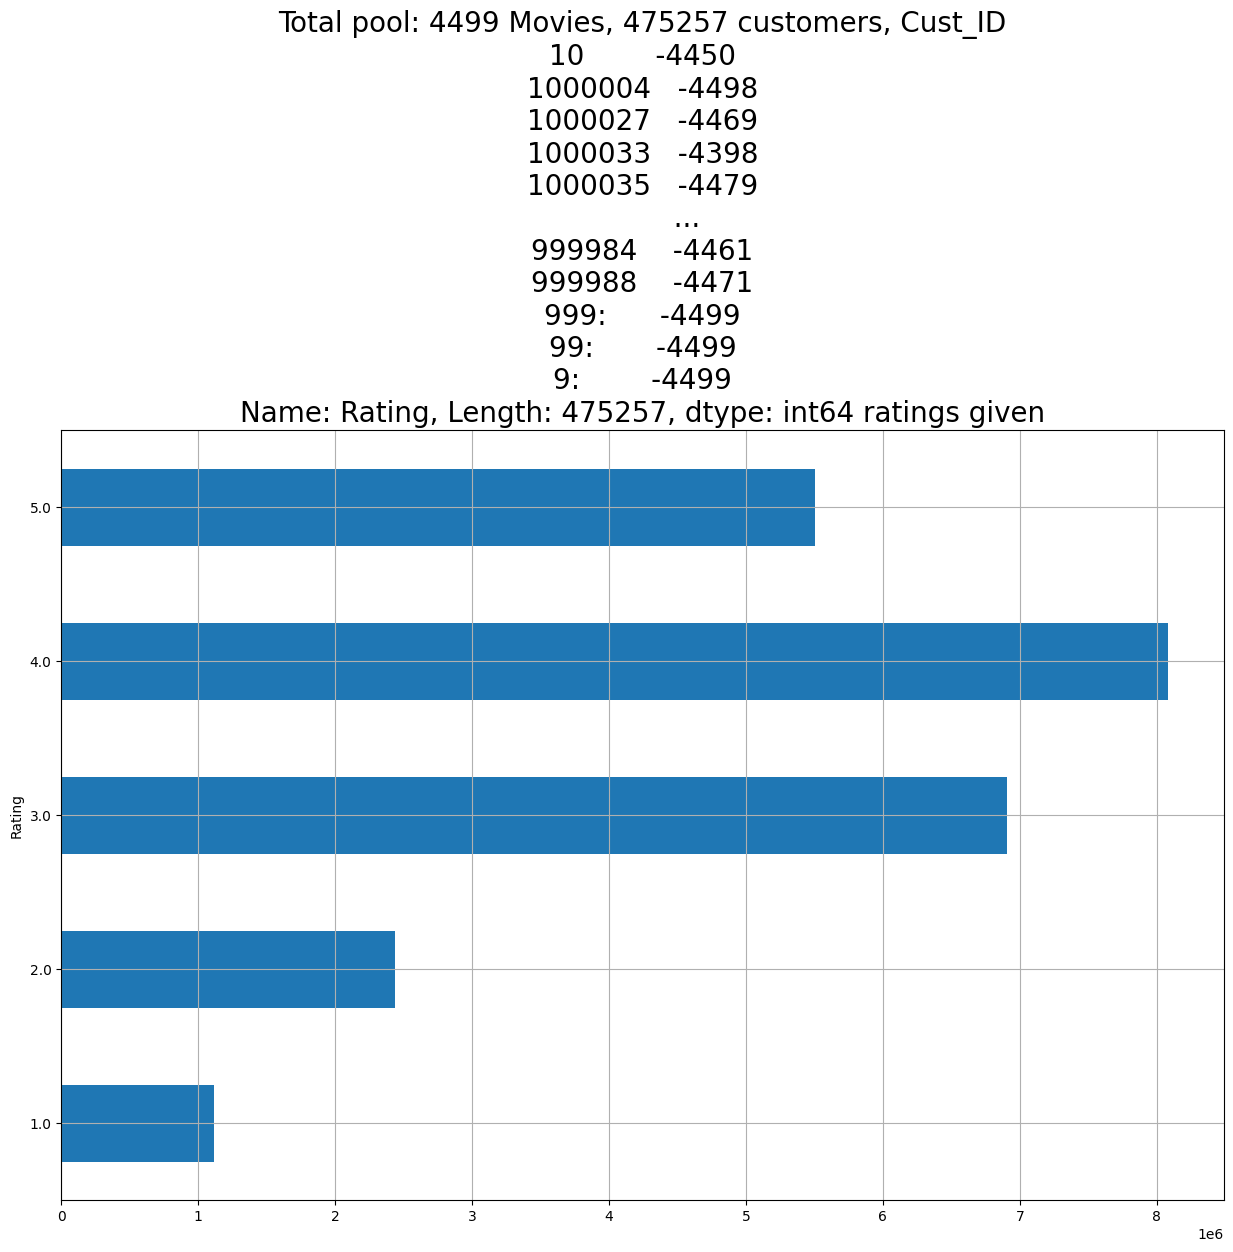

In [13]:
ax = stars.plot(kind = 'barh', legend = False, figsize = (15,10))

plt.title (f'Total pool: {movie_count} Movies, {customer_count} customers, {rating_count} ratings given', fontsize = 20)
plt.grid(True)

In [14]:
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [16]:
# Lets just make a clear dataframe to find how many MovieId are there
movie_id=None
movie_np =[]
# Iterate over the DataFrame rows
for cust_id in netflix_dataset['Cust_ID']:
    if ':' in cust_id:
      # Update the current movie ID
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [17]:
movie_np
# Movie id columns that we can add in our dataset


[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [18]:
#Add the new column to the data frame
netflix_dataset['Movie_ID'] = movie_np

netflix_dataset

,Cust_ID,Rating,Movie_ID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [19]:
netflix_dataset=netflix_dataset[netflix_dataset['Rating'].notna()]
# to keep only the rows where the 'Rating' column is not null (i.e., it excludes rows where the 'Rating' is NaN)

netflix_dataset

,Cust_ID,Rating,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [20]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   object 
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [22]:
# Now we don't have movie if in cust ID column we have removed all 1:NaN, 2: Nan so let's fix the data type now

netflix_dataset["Cust_ID"]=netflix_dataset["Cust_ID"].astype(int)

/tmp/ipython-input-1669877870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_ID"]=netflix_dataset["Cust_ID"].astype(int)


In [23]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [ ]:
#pre - filtering
# now we will remove all the users that have rated less movies and
# also all those movies that has been rated less in numbers

In [24]:
dataset_movie_summary=netflix_dataset.groupby('Movie_ID')['Rating'].agg(['count'])
dataset_movie_summary


,count
Movie_ID,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [25]:
#now we will create a benchmark
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark


908.0

In [26]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_ID', length=2699)

In [27]:
len(drop_movie_list)

2699

In [28]:
#Now we will remove all the users that are in-active

dataset_cust_summary=netflix_dataset.groupby('Cust_ID')['Rating'].agg(['count'])
dataset_cust_summary

,count
Cust_ID,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [29]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [30]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_ID', length=282042)

In [31]:
len(drop_cust_list)

282042

In [ ]:
#Now let's remove all movies that has beenn rated less than 908 times.
#Let's also remove all the customers that have rated less than 36 movies

In [33]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_ID'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_ID'].isin(drop_cust_list)]
print('After the triming, the shape is :{}'. format(netflix_dataset.shape))


After the triming, the shape is :(19695836, 3)


In [34]:
netflix_dataset
# clean netflix data

,Cust_ID,Rating,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [35]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


Model Building

In [38]:
df_title=pd.read_csv("/content/drive/MyDrive/Netflix Movie Titles.csv",encoding = 'latin',header=None, usecols=[0,1,2], names=['Movie_Id', 'Year', 'Name'])

In [39]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17764,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17765,17767,2004.0,Fidel Castro: American Experience
17766,17768,2000.0,Epoch
17767,17769,2003.0,The Company


In [40]:
#install numpy
!pip install surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554980 sha256=0da27c01bf01963c0cc719712692d7fc401dbcef3abf526ea43fffb267eba167
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [41]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [42]:
reader=Reader()
#we only work with top 100k rows for quick runtime.

data=Dataset.load_from_df(netflix_dataset[['Cust_ID', 'Movie_ID', 'Rating']] [:100000], reader)

model=SVD()
#Creating a SVD model

In [43]:
#Trained the model
cross_validate(model, data, measures=['RMSE'], cv=3)

{'test_rmse': array([1.02386711, 1.01336822, 1.01349633]),
 'fit_time': (1.1259281635284424, 0.9309995174407959, 1.3095712661743164),
 'test_time': (0.1399707794189453, 0.16611027717590332, 0.4686431884765625)}

In [ ]:
#Use model for making recommendation for a specific user

In [44]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [45]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17764,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17765,17767,2004.0,Fidel Castro: American Experience
17766,17768,2000.0,Epoch
17767,17769,2003.0,The Company


In [46]:
#Filter the dataset for the specific user you have selected to make recommendation to that user.

user_ratings=netflix_dataset[netflix_dataset ['Cust_ID'] == 1331154]
user_ratings

,Cust_ID,Rating,Movie_ID
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [48]:
#Find the number of unique movies rated by the user

movies_rated_by_user=user_ratings['Movie_ID'].nunique()

print(f"user 1331154 has rated {movies_rated_by_user} unique movies.")

user 1331154 has rated 253 unique movies.


In [49]:
#Making a copy for each individual customer for the recommendation.

copy_data_for_user=df_title.copy()
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17764,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17765,17767,2004.0,Fidel Castro: American Experience
17766,17768,2000.0,Epoch
17767,17769,2003.0,The Company


In [52]:
#Removing the movie less than benchmark for this user.

CLEAN_copy_data_for_user=copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
CLEAN_copy_data_for_user

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17764,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17765,17767,2004.0,Fidel Castro: American Experience
17766,17768,2000.0,Epoch
17767,17769,2003.0,The Company


In [53]:
#Predict the score(rating) that a user (with user ID 1331154) might give to a list of movies.

CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id']. apply (lambda x:model.predict(1331154,x).est)


/tmp/ipython-input-2329590756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id']. apply (lambda x:model.predict(1331154,x).est)


In [54]:
CLEAN_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.879376
4,5,2004.0,The Rise and Fall of ECW,4.109925
5,6,1997.0,Sick,2.998315
7,8,2004.0,What the #$*! Do We Know!?,2.280211
15,16,1996.0,Screamers,2.497488
...,...,...,...,...
17764,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.543373
17765,17767,2004.0,Fidel Castro: American Experience,3.543373
17766,17768,2000.0,Epoch,3.543373
17767,17769,2003.0,The Company,3.543373


In [58]:
CLEAN_copy_data_for_user.sort_values ('Estimate_Score', ascending=False)
#Descending order estimated score

,Movie_Id,Year,Name,Estimate_Score
4,5,2004.0,The Rise and Fall of ECW,4.109925
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.048040
2,3,1997.0,Character,3.879376
27,28,2002.0,Lilo and Stitch,3.601340
17766,17768,2000.0,Epoch,3.543373
...,...,...,...,...
5,6,1997.0,Sick,2.998315
25,26,2004.0,Never Die Alone,2.949027
16,17,2005.0,7 Seconds,2.702407
15,16,1996.0,Screamers,2.497488


In [60]:
top5_movies=CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False).head(5)
top5_movies

,Movie_Id,Year,Name,Estimate_Score
4,5,2004.0,The Rise and Fall of ECW,4.109925
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.048040
2,3,1997.0,Character,3.879376
27,28,2002.0,Lilo and Stitch,3.601340
17766,17768,2000.0,Epoch,3.543373
